In [2]:
import os
import zipfile
import cv2
import numpy as np


In [3]:
pip install torch torchvision scikit-learn matplotlib numpy pillow tqdm

In [4]:
import os
import numpy as np
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import datasets, transforms, models

from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

In [5]:
IMG_SIZE = 224
BATCH_SIZE = 16
NUM_CLASSES = 2
EPOCHS = 20
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

In [6]:
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=3),  # ECG images often grayscale
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
])

In [7]:
import os
import shutil
import random

# ================= CONFIG =================
SOURCE_DIR = "/content/drive/MyDrive/ECG_IMAGES_1"     # your original dataset
DEST_DIR = "dataset"          # new dataset directory

TRAIN_RATIO = 0.7
VAL_RATIO = 0.15
TEST_RATIO = 0.15

SEED = 42
random.seed(SEED)

# =========================================

classes = os.listdir(SOURCE_DIR)

for split in ["train", "val", "test"]:
    for cls in classes:
        os.makedirs(os.path.join(DEST_DIR, split, cls), exist_ok=True)

for cls in classes:
    class_path = os.path.join(SOURCE_DIR, cls)
    images = os.listdir(class_path)
    random.shuffle(images)

    total = len(images)
    train_end = int(total * TRAIN_RATIO)
    val_end = train_end + int(total * VAL_RATIO)

    train_imgs = images[:train_end]
    val_imgs = images[train_end:val_end]
    test_imgs = images[val_end:]

    for img in train_imgs:
        shutil.copy(
            os.path.join(class_path, img),
            os.path.join(DEST_DIR, "train", cls, img)
        )

    for img in val_imgs:
        shutil.copy(
            os.path.join(class_path, img),
            os.path.join(DEST_DIR, "val", cls, img)
        )

    for img in test_imgs:
        shutil.copy(
            os.path.join(class_path, img),
            os.path.join(DEST_DIR, "test", cls, img)
        )

print("✅ Dataset split completed successfully!")

✅ Dataset split completed successfully!


In [8]:
train_dir = "/content/dataset/train"
val_dir = "/content/dataset/val"

train_dataset = datasets.ImageFolder(train_dir, transform=train_transform)
val_dataset = datasets.ImageFolder(val_dir, transform=val_transform)

In [9]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [10]:
from collections import Counter

def count_images(path):
    counts = {}
    for cls in os.listdir(path):
        counts[cls] = len(os.listdir(os.path.join(path, cls)))
    return counts

print("Train:", count_images("/content/dataset/train"))
print("Val:", count_images("/content/dataset/val"))
print("Test:", count_images("/content/dataset/test"))

Train: {'Normal Person ECG Images (859)': 601, 'ECG Images of Patient that have abnormal heart beats (548)': 382}
Val: {'Normal Person ECG Images (859)': 128, 'ECG Images of Patient that have abnormal heart beats (548)': 81}
Test: {'Normal Person ECG Images (859)': 130, 'ECG Images of Patient that have abnormal heart beats (548)': 83}


handling class imbalance


In [11]:
class_counts = np.bincount(train_dataset.targets)
class_weights = 1. / class_counts
sample_weights = class_weights[train_dataset.targets]

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

In [12]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [13]:
import os

def count_images_per_class(dataset_path):
    class_counts = {}
    for cls in os.listdir(dataset_path):
        cls_path = os.path.join(dataset_path, cls)
        if os.path.isdir(cls_path):
            class_counts[cls] = len([
                img for img in os.listdir(cls_path)
                if img.lower().endswith(('.png', '.jpg', '.jpeg'))
            ])
    return class_counts

print("Train set:", count_images_per_class("dataset/train"))
print("Validation set:", count_images_per_class("dataset/val"))
print("Test set:", count_images_per_class("dataset/test"))

Train set: {'Normal Person ECG Images (859)': 601, 'ECG Images of Patient that have abnormal heart beats (548)': 382}
Validation set: {'Normal Person ECG Images (859)': 128, 'ECG Images of Patient that have abnormal heart beats (548)': 81}
Test set: {'Normal Person ECG Images (859)': 130, 'ECG Images of Patient that have abnormal heart beats (548)': 83}


In [14]:
import numpy as np
from collections import Counter

targets = train_dataset.targets  # class labels
class_counts = Counter(targets)

print("Original class distribution:")
for cls, count in class_counts.items():
    print(f"Class {cls}: {count} images")

# Effective sampling per epoch
sampled_indices = list(train_loader.sampler)
sampled_targets = [targets[i] for i in sampled_indices]
sampled_counts = Counter(sampled_targets)

print("\nEffective distribution per epoch (after imbalance handling):")
for cls, count in sampled_counts.items():
    print(f"Class {cls}: {count} samples")

Original class distribution:
Class 0: 382 images
Class 1: 601 images

Effective distribution per epoch (after imbalance handling):
Class 0: 488 samples
Class 1: 495 samples


Classes: ['ECG Images of Patient that have abnormal heart beats (548)', 'Normal Person ECG Images (859)']
Downloading: "https://download.pytorch.org/models/densenet201-c1103571.pth" to /root/.cache/torch/hub/checkpoints/densenet201-c1103571.pth


100%|██████████| 77.4M/77.4M [00:00<00:00, 172MB/s]



Epoch 1/15
Train Loss: 0.6065, Train Acc: 0.6958
Val Loss: 0.5263, Val Acc: 0.6986

Epoch 2/15
Train Loss: 0.4948, Train Acc: 0.7813
Val Loss: 0.4300, Val Acc: 0.8421

Epoch 3/15
Train Loss: 0.4378, Train Acc: 0.8423
Val Loss: 0.3911, Val Acc: 0.8373

Epoch 4/15
Train Loss: 0.4144, Train Acc: 0.8240
Val Loss: 0.3618, Val Acc: 0.8469

Epoch 5/15
Train Loss: 0.3908, Train Acc: 0.8342
Val Loss: 0.3530, Val Acc: 0.8517

Epoch 6/15
Train Loss: 0.3754, Train Acc: 0.8332
Val Loss: 0.3457, Val Acc: 0.8517

Epoch 7/15
Train Loss: 0.3552, Train Acc: 0.8586
Val Loss: 0.3455, Val Acc: 0.8325

Epoch 8/15
Train Loss: 0.3363, Train Acc: 0.8647
Val Loss: 0.3292, Val Acc: 0.8517

Epoch 9/15
Train Loss: 0.3329, Train Acc: 0.8576
Val Loss: 0.3202, Val Acc: 0.8612

Epoch 10/15
Train Loss: 0.3427, Train Acc: 0.8515
Val Loss: 0.3126, Val Acc: 0.8660

Epoch 11/15
Train Loss: 0.3396, Train Acc: 0.8566
Val Loss: 0.3108, Val Acc: 0.8612

Epoch 12/15
Train Loss: 0.3265, Train Acc: 0.8586
Val Loss: 0.3190, Val A

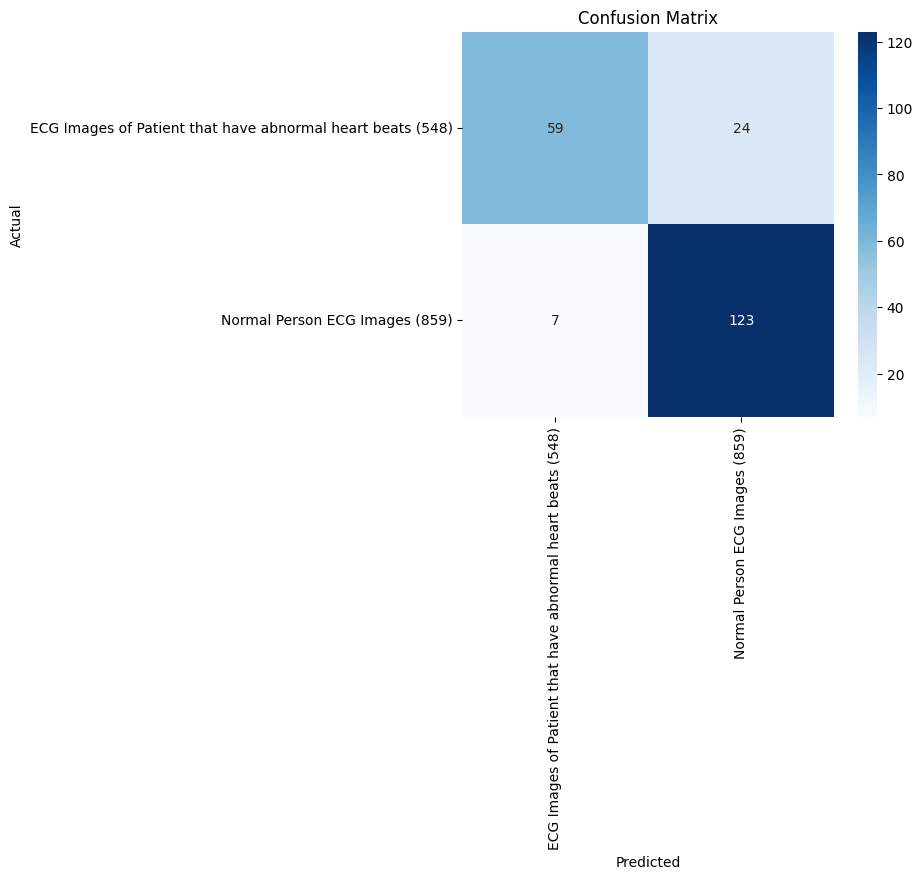

In [16]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import copy

# ----------------------------
# ⚙️ Config
# ----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

BATCH_SIZE = 32
EPOCHS = 15
LR = 0.0003
NUM_CLASSES = 2   # Normal vs Abnormal

train_dir = "dataset/train"
val_dir   = "dataset/val"
test_dir  = "dataset/test"

# ----------------------------
# 🔄 Transforms (IMPORTANT for DenseNet)
# ----------------------------
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# ----------------------------
# 📂 Load Data
# ----------------------------
train_dataset = datasets.ImageFolder(train_dir, transform=train_transform)
val_dataset   = datasets.ImageFolder(val_dir, transform=val_test_transform)
test_dataset  = datasets.ImageFolder(test_dir, transform=val_test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

class_names = train_dataset.classes
print("Classes:", class_names)

# ----------------------------
# 🧠 Load DenseNet201
# ----------------------------
model = models.densenet201(weights="IMAGENET1K_V1")

# Freeze backbone (optional but recommended initially)
for param in model.features.parameters():
    param.requires_grad = False

# Replace classifier
model.classifier = nn.Linear(model.classifier.in_features, NUM_CLASSES)
model = model.to(device)

# ----------------------------
# ⚖️ Loss + Optimizer
# ----------------------------
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

# ----------------------------
# 🔁 Training + Validation
# ----------------------------
best_val_acc = 0.0
best_model_wts = copy.deepcopy(model.state_dict())

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")

    # ---- Training ----
    model.train()
    train_loss = 0.0
    correct = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct += torch.sum(preds == labels).item()

    train_acc = correct / len(train_dataset)

    # ---- Validation ----
    model.eval()
    val_loss = 0.0
    correct = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct += torch.sum(preds == labels).item()

    val_acc = correct / len(val_dataset)

    print(f"Train Loss: {train_loss/len(train_loader):.4f}, Train Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss/len(val_loader):.4f}, Val Acc: {val_acc:.4f}")

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_wts = copy.deepcopy(model.state_dict())

# Load best model
model.load_state_dict(best_model_wts)

# ----------------------------
# 🧪 Test Evaluation
# ----------------------------
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)

        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

# ----------------------------
# 📊 Classification Report
# ----------------------------
print("\nClassification Report:\n")
print(classification_report(all_labels, all_preds, target_names=class_names))

# ----------------------------
# 📉 Confusion Matrix
# ----------------------------
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [17]:
train_losses = [0.6065, 0.4948, 0.4378, 0.4144, 0.3908, 0.3754, 0.3552, 0.3363, 0.3329, 0.3427, 0.3396, 0.3265, 0.3462, 0.3399, 0.3325]

val_losses = [0.5263, 0.4300, 0.3911, 0.3618, 0.3530, 0.3457, 0.3455, 0.3292, 0.3202, 0.3126, 0.3108, 0.3190, 0.3075, 0.3128, 0.3311]

train_acc = [0.6958, 0.7813, 0.8423, 0.8240, 0.8342, 0.8332, 0.8586, 0.8647, 0.8576, 0.8515, 0.8566, 0.8586, 0.8372, 0.8433, 0.8576]

val_acc = [0.6986, 0.8421, 0.8373, 0.8469, 0.8517, 0.8517, 0.8325, 0.8517, 0.8612, 0.8660, 0.8612, 0.8421, 0.8612, 0.8517, 0.8373]

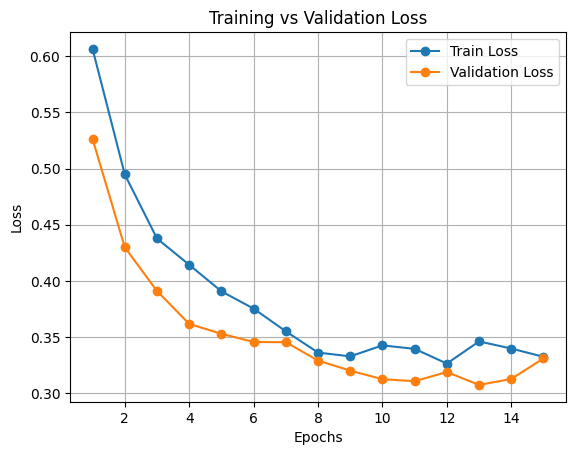

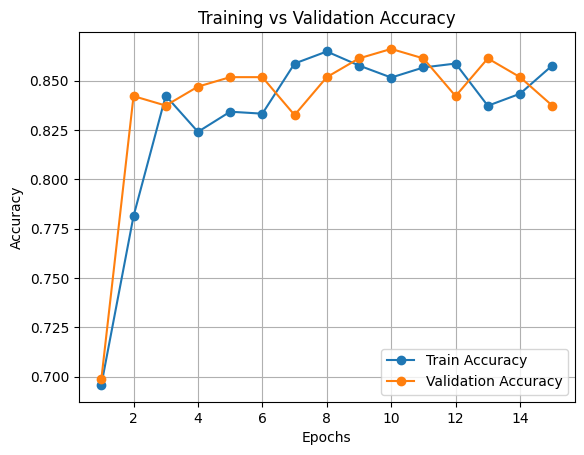

In [18]:
import matplotlib.pyplot as plt

epochs = range(1, 16)

# ----------------------------
# 📉 Loss Graph
# ----------------------------
plt.figure()
plt.plot(epochs, train_losses, marker='o', label='Train Loss')
plt.plot(epochs, val_losses, marker='o', label='Validation Loss')

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid()
plt.show()

# ----------------------------
# 📈 Accuracy Graph
# ----------------------------
plt.figure()
plt.plot(epochs, train_acc, marker='o', label='Train Accuracy')
plt.plot(epochs, val_acc, marker='o', label='Validation Accuracy')

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid()
plt.show()